# Gåshamna Whale Bone Cluster Analysis: Documentation

## 1. Objective
The goal of this analysis is to identify discrete **activity zones** (butchery sites, tryworks, or disposal pits) within the Gåshamna whaling station. 

While automated statistical methods (like Knee-point detection) often group all finds into a single "mega-cluster" because the site is so dense, this script uses **archaeologically justified constraints** to separate distinct functional areas.

---

## 2. Methodology: Manual DBSCAN
The analysis utilizes the **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) algorithm. Unlike other methods, DBSCAN does not require us to pre-define the number of clusters. Instead, it relies on two human-defined parameters:

### A. The Spatial Threshold (`eps = 2.5m`)
In statistical terms, `eps` defines the maximum distance between two bones for them to be considered "neighbors." 

* **The Logic:** On a 17th-century whaling station, processing areas (tryworks) and their associated waste piles were compact. 
* **The Scale:** A distance of **2.5 meters** represents a "human-scale" interaction zone. If bones are further apart than this, they likely represent separate events or secondary scatter.
* **Correction:** We explicitly rejected the automated suggestion of ~14m, as it failed to distinguish between individual structures.

### B. The Density Threshold (`min_samples = 8`)
This defines the minimum number of bone elements required to form a "Cluster."

* **The Logic:** Single elements can be moved by taphonomic processes (bears, ice, meltwater).
* **The Scale:** By requiring a minimum of **8 elements**, we filter out "Noise" and focus only on **primary depositional features**.

---

## 3. Technical Workflow
1. **Species Isolation:** Filters the dataset specifically for "Whale" remains.
2. **Coordinate Extraction:** Projects XY coordinates into a 2D Euclidean space.
3. **Clustering Execution:** Labels points as **Core Points** or **Noise (-1)**.
4. **Geometry Generation:** Creates organic "Activity Envelopes" around clusters.
5. **Export:** Saves results to a Multi-layer GeoPackage and a high-resolution PNG map.

---

## 4. Geometry Generation: Organic Activity Envelopes
To represent the "footprint" of each activity zone, polygons are generated using a **Buffer-and-Dissolve** technique.

* **The Process:** Each bone in a cluster is given a spatial buffer (approx. 70% of the `eps`). These are merged via a `unary_union` operation.
* **Smoothing:** The resulting shapes are simplified (`simplify(0.2)`) to produce "soft" organic edges, which better represent the fuzzy boundaries of archaeological features compared to rigid geometric hulls.
* **Interpretation:** These polygons represent the likely extent of the original depositional feature (e.g., the area of a blubber-cutting platform).

---

## 5. Implementation Summary (Python)

```python
# 1. Cluster Calculation
db = DBSCAN(eps=2.5, min_samples=8).fit(coords)
whale_bones['cluster_id'] = db.labels_

# 2. Polygon Fallback (Buffer-Dissolve)
# Used due to library version constraints (Shapely < 2.0)
buffered = cluster_points.buffer(2.5 * 0.7)
unified_shape = unary_union(buffered).simplify(0.2)

Success! Image saved to: D:\Spitzbergen_2022\Sites\Gashamnda\GAS_stats\Whale_Cluster_Map.png


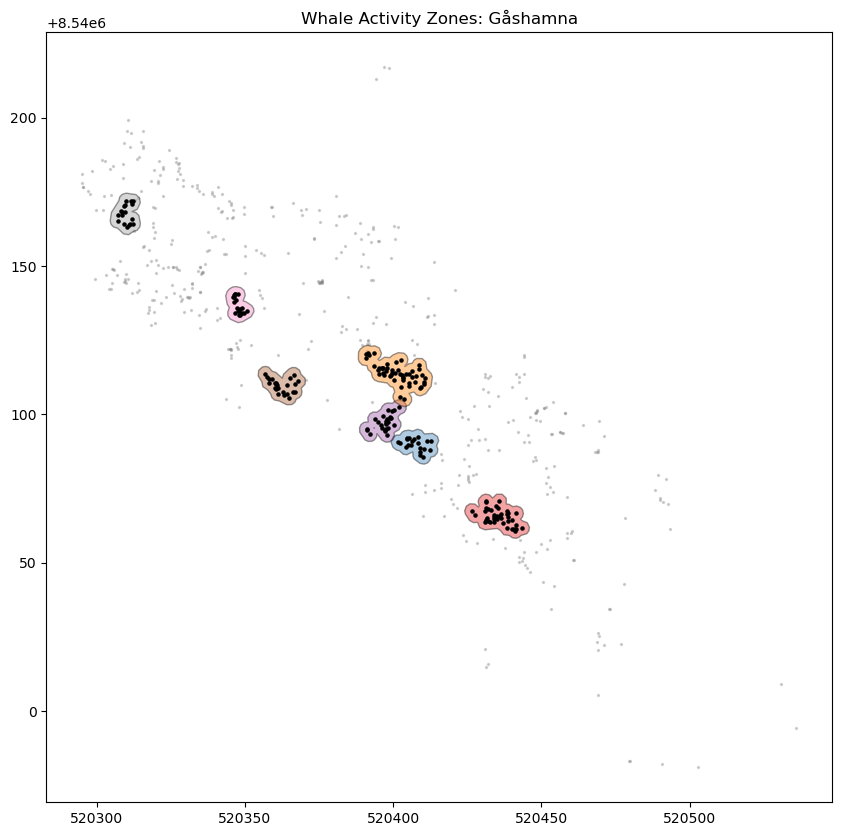

In [30]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.cluster import DBSCAN
from shapely.ops import unary_union

# =================================================================
# 1. SETTINGS
# =================================================================
base_path = r'D:\Spitzbergen_2022\Sites\Gashamnda\GAS_stats'
input_name = 'GAS_unified.gpkg'
output_name = 'Gashamna_Whale_Clusters_Final.gpkg'

points_path = os.path.join(base_path, input_name)
output_path = os.path.join(base_path, output_name)
output_image = os.path.join(base_path, 'Whale_Cluster_Map.png')

eps_manual = 5
min_samples = 15

# =================================================================
# 2. PROCESSING
# =================================================================
if not os.path.exists(points_path):
    print(f"Error: {points_path} not found.")
else:
    bones = gpd.read_file(points_path)
    spec_col = next((c for c in ['species', 'species_clean', 'Art'] if c in bones.columns), 'species')
    whale_bones = bones[bones[spec_col].str.contains('Whale', case=False, na=False)].copy()

    coords = np.array(list(zip(whale_bones.geometry.x, whale_bones.geometry.y)))
    db = DBSCAN(eps=eps_manual, min_samples=min_samples).fit(coords)
    whale_bones['cluster_id'] = db.labels_

    # Create Polygons
    cluster_polygons = []
    for cid in sorted(whale_bones['cluster_id'].unique()):
        if cid == -1: continue
        points = whale_bones[whale_bones['cluster_id'] == cid].geometry
        poly = unary_union(points.buffer(eps_manual * 0.5)).simplify(0.2)
        cluster_polygons.append({'cluster_id': cid, 'geometry': poly})
    
    gdf_poly = gpd.GeoDataFrame(cluster_polygons, crs=whale_bones.crs)

    # =================================================================
    # 3. PLOT & SAVE (Order: Save then Show)
    # =================================================================
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Plot Noise
    whale_bones[whale_bones['cluster_id'] == -1].plot(ax=ax, color='grey', markersize=2, alpha=0.3)
    # Plot Polygons
    if not gdf_poly.empty:
        gdf_poly.plot(ax=ax, column='cluster_id', cmap='Set1', alpha=0.4, edgecolor='black')
    # Plot Clusters
    whale_bones[whale_bones['cluster_id'] != -1].plot(ax=ax, color='black', markersize=5)

    ax.set_title('Whale Activity Zones: Gåshamna')
    ax.set_aspect('equal')

    # SAVE FIRST
    plt.savefig(output_image, dpi=300, bbox_inches='tight')
    print(f"Success! Image saved to: {output_image}")

    # EXPORT DATA
    whale_bones.to_file(output_path, layer='Points', driver="GPKG")
    gdf_poly.to_file(output_path, layer='Polygons', driver="GPKG")

    # SHOW SECOND
    plt.show()